# Budget de calibration — NIST 14 & 16 SEER

Le FDD par résidus exige une référence saine sur la **machine en service**.
Sans elle le leave-one-machine-out plafonne à **0,318** ; avec tous les essais sains de la
machine cible on retrouve **0,602** (`EDA_NIST_reference.ipynb`).

**Question :** combien d'essais sains de la machine cible faut-il pour passer de 0,318 à 0,602 ?

Chargement, étiquetage (tolérance 2 %) et conversions : mêmes que `EDA_NIST_model.ipynb`.

### Protocole

- Leave-one-machine-out, les deux sens, moyenne.
- `GradientBoostingClassifier(random_state=42)` entraîné **uniquement** sur la machine d'entraînement.
- Huit résidus seuls. Référence saine : kNN, médiane des `k=min(5, n)` plus proches en `(T_source, T_sink)`.
- `n ∈ {0, 1, 5, 10, 20, 50, all}` essais sains **de la machine de test** pour la référence.
  `n = 0` : référence = sains de la machine d'entraînement. `n = all` : tous les sains de test.
- 20 tirages (seeds 0–19). Moyenne et percentiles 10/90.

### Piège 🔴

Les `n` essais sains tirés de la machine de test construisent la référence **et sont retirés
du jeu de test**. Sinon `No_Fault` est noté sur des points qui ont servi au barème — la courbe
monte pour de mauvaises raisons.

Exception : `n = all` reproduit le protocole publié (0,602) : tous les sains restent dans le
test, comme dans `EDA_NIST_model.ipynb`. C'est le contrôle de borne, pas un point intermédiaire.

Contrôles avant d'interpréter : `n = 0` → **0,318** ; `n = all` → **0,602**.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NIST = ROOT / 'data' / 'nist'
assert (NIST / 'fdd_1416seer.xlsx').exists(), 'Placer les xlsx NIST dans data/nist/ (non versionnés).'

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
    'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})

F2C = lambda s: (s - 32) * 5 / 9
dF2K = lambda s: s * 5 / 9
PSI2BAR, BTU2W = 0.0689476, 0.293071

df = pd.read_excel(NIST / 'fdd_1416seer.xlsx')

FAULTCOLS = {'EF': 'Evap_Airflow', 'CF': 'Cond_Blockage', 'LL': 'LiquidLine', 'UC/OC': 'Charge'}

def fault_label(row, tol=2.0):
    active = []
    for col, name in FAULTCOLS.items():
        v = row[col]
        if pd.isna(v) or abs(v - 100) <= tol:
            continue
        if name == 'Charge':
            name = 'Undercharge' if v < 100 else 'Overcharge'
        active.append(name)
    if not active:
        return 'No_Fault'
    return active[0] if len(active) == 1 else 'MULTI:' + '+'.join(sorted(active))

df['fault_class'] = df.apply(fault_label, axis=1)

m16 = df.Rated_SEER == 16.0
assert (df.loc[m16, '1710_ODSuctPort_psia'] == df.loc[m16, 'CompDisch_psia']).all()

X = pd.DataFrame(index=df.index)
X['P_evap'] = df['1701_ODVapSV_psia'] * PSI2BAR
X['P_cond'] = df['CompDisch_psia'] * PSI2BAR
X['pressure_ratio'] = X.P_cond / X.P_evap
X['T_suction'] = F2C(df['1608_CompSuct_TempF'])
X['T_discharge'] = F2C(df['1617_CompDisch_TempF'])
X['T_evap'] = F2C(df['CompSuct_Tsat_F'])
X['T_cond'] = F2C(df['CompDisch_Tsat_F'])
X['superheat'] = dF2K(df['CompSuct_Suph_F'])
X['subcooling'] = dF2K(df['ODLiqSV_Tsub_F'])
X['Q_evap'] = df['TOTAL Capacity (Btu/h)'] * BTU2W
X['W_od'] = df['OD_Xitron_Watts']
X['COP'] = df['COP']
X['T_source'] = F2C(df['Inlet TC Grid AVG Temp (F)'])
X['T_sink'] = F2C(df['OD Air AVG DB (F)'])
X['delta_T_evap'] = X.T_source - X.T_evap
X['delta_T_cond'] = X.T_cond - X.T_sink

LEAK = ['EF', 'CF', 'LL', 'UC/OC', 'NF']
assert not any(c in X.columns for c in LEAK)

y, grp = df.fault_class, df.Rated_SEER
keep = grp.isin([14.0, 16.0]) & (~y.str.startswith('MULTI')) & X.notna().all(axis=1)
X, y, grp = X.loc[keep].copy(), y.loc[keep].copy(), grp.loc[keep].copy()

RES = ['superheat', 'subcooling', 'T_discharge', 'COP', 'W_od', 'P_evap', 'P_cond', 'pressure_ratio']
COND = ['T_source', 'T_sink']
DCOLS = ['d_' + c for c in RES]
MAJ = 0.251
ACC0, ACC_ALL = 0.318, 0.602
TARGET90 = ACC0 + 0.9 * (ACC_ALL - ACC0)

print(f'{len(X)} lignes · {y.nunique()} classes')
print('sains par machine :', dict(y[y == 'No_Fault'].groupby(grp).size()))
print(f'seuil 90 % du gain : {TARGET90:.3f}')

5386 lignes · 6 classes
sains par machine : {14.0: np.int64(727), 16.0: np.int64(625)}
seuil 90 % du gain : 0.574


## Un classifieur par pli, des références qui varient

Les résidus d'**entraînement** ne dépendent pas de `n` : kNN sur tous les sains de la machine
d'entraînement. Le classifieur est donc ajusté **une fois par pli**. Seule la référence du
**test** change avec `n`.

In [2]:
def knn_predict(Xh_cond, Xh_res, X_cond, k=5):
    k = min(int(k), len(Xh_cond))
    tree = cKDTree(np.asarray(Xh_cond, dtype=float))
    _, idx = tree.query(np.asarray(X_cond, dtype=float), k=k)
    if idx.ndim == 1:
        idx = idx[:, None]
    return np.median(np.asarray(Xh_res)[idx], axis=1)


def farthest_point_sample(cond, n, rng):
    """n indices (positions) répartis : greedy maximin sur (T_source, T_sink)."""
    z = np.asarray(cond, dtype=float)
    z = (z - z.mean(0)) / np.clip(z.std(0), 1e-9, None)
    m = len(z)
    chosen = [int(rng.integers(0, m))]
    dmin = np.linalg.norm(z - z[chosen[0]], axis=1)
    for _ in range(1, n):
        j = int(np.argmax(dmin))
        chosen.append(j)
        dmin = np.minimum(dmin, np.linalg.norm(z - z[j], axis=1))
    return np.array(chosen, dtype=int)


N_GRID = [0, 1, 5, 10, 20, 50, 'all']
N_SEEDS = 20

# Classifieur + résidus train : une fois par machine d'entraînement.
folds = {}
for test_seer in (14.0, 16.0):
    tr = (grp != test_seer)
    te = (grp == test_seer)
    h_tr = tr & (y == 'No_Fault')
    pred_tr = knn_predict(X.loc[h_tr, COND], X.loc[h_tr, RES], X.loc[tr, COND], k=5)
    Dtr = pd.DataFrame(X.loc[tr, RES].to_numpy() - pred_tr, index=X.index[tr], columns=DCOLS)
    clf = GradientBoostingClassifier(random_state=42).fit(Dtr, y.loc[tr])
    folds[test_seer] = {
        'tr': tr, 'te': te, 'h_tr': h_tr, 'clf': clf,
        'h_te_idx': X.index[te & (y == 'No_Fault')].to_numpy(),
    }
    print(f'test {int(test_seer)} SEER · sains train={int(h_tr.sum())} · sains test={len(folds[test_seer]["h_te_idx"])} · n_test={int(te.sum())}')

test 14 SEER · sains train=625 · sains test=727 · n_test=2420


test 16 SEER · sains train=727 · sains test=625 · n_test=2966


In [3]:
def evaluate(n, seed, spread=False):
    """Accuracy / F1 macro, moyenne des deux plis, un tirage."""
    accs, f1s = [], []
    rng = np.random.default_rng(seed)
    for test_seer in (14.0, 16.0):
        f = folds[test_seer]
        te, h_tr, h_te_idx, clf = f['te'], f['h_tr'], f['h_te_idx'], f['clf']
        te_eval = te.copy()

        if n == 0:
            src_idx = X.index[h_tr]
            k = 5
        elif n == 'all':
            src_idx = h_te_idx
            k = 5
        else:
            n = int(n)
            if spread:
                pos = farthest_point_sample(X.loc[h_te_idx, COND], n, rng)
                src_idx = h_te_idx[pos]
            else:
                src_idx = rng.choice(h_te_idx, size=n, replace=False)
            k = min(5, n)
            te_eval.loc[src_idx] = False  # piège n°1 : retirés du test

        pred_te = knn_predict(X.loc[src_idx, COND], X.loc[src_idx, RES], X.loc[te, COND], k=k)
        Dte = pd.DataFrame(X.loc[te, RES].to_numpy() - pred_te, index=X.index[te], columns=DCOLS)
        eval_idx = X.index[te_eval]
        hat = clf.predict(Dte.loc[eval_idx])
        yte = y.loc[eval_idx]
        accs.append(accuracy_score(yte, hat))
        f1s.append(f1_score(yte, hat, average='macro'))
    return float(np.mean(accs)), float(np.mean(f1s))


records = []
print('contrôles de borne (un tirage, déterministes)…', flush=True)
acc_n0, f1_n0 = evaluate(0, seed=0)
acc_all, f1_all = evaluate('all', seed=0)
print(f'  n=0    acc={acc_n0:.3f}  f1={f1_n0:.3f}   (cible 0,318 / 0,290)')
print(f'  n=all  acc={acc_all:.3f}  f1={f1_all:.3f}   (cible 0,602 / 0,479)')

ok0 = abs(acc_n0 - ACC0) < 0.02
okall = abs(acc_all - ACC_ALL) < 0.02
if not (ok0 and okall):
    raise RuntimeError(
        f'bornes non retrouvées (n=0 {acc_n0:.3f}, n=all {acc_all:.3f}). '
        'Protocole mal implémenté — on s\'arrête.'
    )
print('bornes OK.\n')

for n in N_GRID:
    n_seeds = 1 if n in (0, 'all') else N_SEEDS
    acc_s, f1_s = [], []
    for s in range(n_seeds):
        a, f = evaluate(n, seed=s, spread=False)
        acc_s.append(a)
        f1_s.append(f)
        if n not in (0, 'all'):
            print(f'n={n:>3}  seed={s:02d}  acc={a:.3f}  f1={f:.3f}', flush=True)
    records.append({
        'n': n,
        'tirage': 'aléatoire',
        'acc_mean': float(np.mean(acc_s)),
        'acc_p10': float(np.percentile(acc_s, 10)),
        'acc_p90': float(np.percentile(acc_s, 90)),
        'f1_mean': float(np.mean(f1_s)),
        'f1_p10': float(np.percentile(f1_s, 10)),
        'f1_p90': float(np.percentile(f1_s, 90)),
        'n_seeds': n_seeds,
    })

curve = pd.DataFrame(records)
curve

contrôles de borne (un tirage, déterministes)…


  n=0    acc=0.318  f1=0.290   (cible 0,318 / 0,290)
  n=all  acc=0.602  f1=0.479   (cible 0,602 / 0,479)
bornes OK.

n=  1  seed=00  acc=0.310  f1=0.308


n=  1  seed=01  acc=0.426  f1=0.333


n=  1  seed=02  acc=0.271  f1=0.280


n=  1  seed=03  acc=0.400  f1=0.356


...

n= 50  seed=16  acc=0.471  f1=0.408


n= 50  seed=17  acc=0.462  f1=0.384


n= 50  seed=18  acc=0.461  f1=0.384


n= 50  seed=19  acc=0.439  f1=0.364


,n,tirage,acc_mean,acc_p10,acc_p90,f1_mean,f1_p10,f1_p90,n_seeds
0,0,aléatoire,0.317796,0.317796,0.317796,0.290100,0.290100,0.290100,1
1,1,aléatoire,0.289907,0.204093,0.400734,0.270631,0.201856,0.347938,20
2,5,aléatoire,0.313682,0.225676,0.381903,0.289235,0.214217,0.334339,20
3,10,aléatoire,0.376821,0.345041,0.404302,0.324186,0.300127,0.342096,20
4,20,aléatoire,0.409288,0.377853,0.438069,0.349045,0.325531,0.378521,20
5,50,aléatoire,0.455629,0.437656,0.473887,0.380493,0.363866,0.399767,20
6,all,aléatoire,0.602479,0.602479,0.602479,0.479125,0.479125,0.479125,1


In [4]:
# Variante : n points répartis sur (T_source, T_sink) plutôt que tirés au hasard.
spread_rows = []
for n in (5, 10, 20, 50):
    acc_s, f1_s = [], []
    for s in range(N_SEEDS):
        a, f = evaluate(n, seed=s, spread=True)
        acc_s.append(a)
        f1_s.append(f)
    spread_rows.append({
        'n': n,
        'tirage': 'réparti',
        'acc_mean': float(np.mean(acc_s)),
        'acc_p10': float(np.percentile(acc_s, 10)),
        'acc_p90': float(np.percentile(acc_s, 90)),
        'f1_mean': float(np.mean(f1_s)),
        'f1_p10': float(np.percentile(f1_s, 10)),
        'f1_p90': float(np.percentile(f1_s, 90)),
        'n_seeds': N_SEEDS,
    })
    print(f'réparti n={n:>2}  acc={np.mean(acc_s):.3f}  [{np.percentile(acc_s,10):.3f}, {np.percentile(acc_s,90):.3f}]')

spread = pd.DataFrame(spread_rows)
cmp = curve[curve.n.isin([5, 10, 20, 50])][['n', 'acc_mean', 'f1_mean']].merge(
    spread[['n', 'acc_mean', 'f1_mean']], on='n', suffixes=('_aléatoire', '_réparti')
)
cmp['Δ acc'] = (cmp['acc_mean_réparti'] - cmp['acc_mean_aléatoire']).round(3)
cmp.round(3)

réparti n= 5  acc=0.391  [0.367, 0.445]


réparti n=10  acc=0.405  [0.378, 0.435]


réparti n=20  acc=0.442  [0.431, 0.456]


réparti n=50  acc=0.475  [0.467, 0.483]


,n,acc_mean_aléatoire,f1_mean_aléatoire,acc_mean_réparti,f1_mean_réparti,Δ acc
0,5,0.314,0.289,0.391,0.329,0.077
1,10,0.377,0.324,0.405,0.343,0.028
2,20,0.409,0.349,0.442,0.368,0.033
3,50,0.456,0.380,0.475,0.394,0.019


figure → docs/calibration_budget.png

Aucun n fini sur la grille n'atteint 0.574. À n=50 : acc=0.456. Il faut essentiellement tous les sains (n=all → 0.602).
  n  acc_mean  acc_p10  acc_p90  f1_mean
  0  0.317796 0.317796 0.317796 0.290100
  1  0.289907 0.204093 0.400734 0.270631
  5  0.313682 0.225676 0.381903 0.289235
 10  0.376821 0.345041 0.404302 0.324186
 20  0.409288 0.377853 0.438069 0.349045
 50  0.455629 0.437656 0.473887 0.380493
all  0.602479 0.602479 0.602479 0.479125


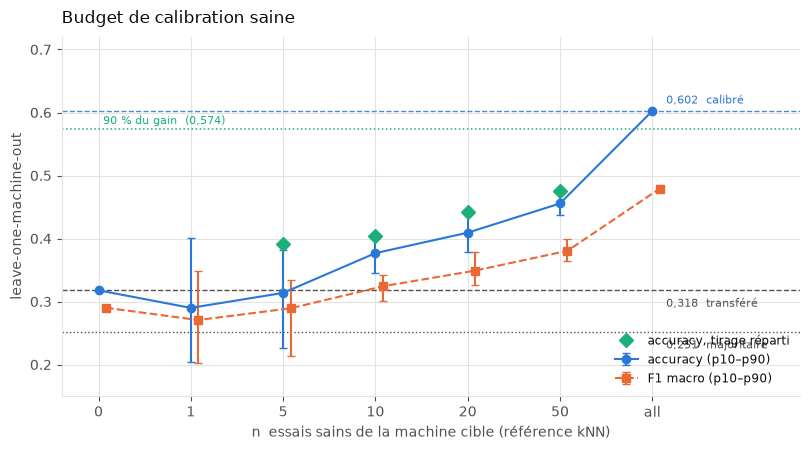

In [5]:
def n_to_x(n):
    return {0: 0, 1: 1, 5: 2, 10: 3, 20: 4, 50: 5, 'all': 6}[n]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
xs = [n_to_x(n) for n in curve.n]
yerr_lo = curve.acc_mean - curve.acc_p10
yerr_hi = curve.acc_p90 - curve.acc_mean
ax.errorbar(xs, curve.acc_mean, yerr=[yerr_lo, yerr_hi], fmt='o-', color=BLUE,
            capsize=3, label='accuracy (p10–p90)', zorder=3)
yerr_lo = curve.f1_mean - curve.f1_p10
yerr_hi = curve.f1_p90 - curve.f1_mean
ax.errorbar([x + 0.08 for x in xs], curve.f1_mean, yerr=[yerr_lo, yerr_hi], fmt='s--',
            color=ORANGE, capsize=3, label='F1 macro (p10–p90)', zorder=3)

if len(spread):
    ax.plot([n_to_x(n) for n in spread.n], spread.acc_mean, 'D', color=AQUA,
            markersize=7, label='accuracy, tirage réparti', zorder=4)

ax.axhline(ACC_ALL, color=BLUE, ls='--', lw=1.0, alpha=0.85)
ax.text(6.15, ACC_ALL + 0.008, '0,602  calibré', color=BLUE, fontsize=8, va='bottom')
ax.axhline(ACC0, color=MUTED, ls='--', lw=1.0)
ax.text(6.15, ACC0 - 0.012, '0,318  transféré', color=MUTED, fontsize=8, va='top')
ax.axhline(MAJ, color=MUTED, ls=':', lw=1.0)
ax.text(6.15, MAJ - 0.012, '0,251  majoritaire', color=MUTED, fontsize=8, va='top')
ax.axhline(TARGET90, color=AQUA, ls=':', lw=1.1)
ax.text(0.05, TARGET90 + 0.008, '90 % du gain  (0,574)', color=AQUA, fontsize=8)

ax.set_xticks(range(7))
ax.set_xticklabels(['0', '1', '5', '10', '20', '50', 'all'])
ax.set_xlabel('n  essais sains de la machine cible (référence kNN)')
ax.set_ylabel('leave-one-machine-out')
ax.set_ylim(0.15, 0.72)
ax.set_xlim(-0.4, 7.6)
ax.set_title('Budget de calibration saine', loc='left', color=INK, pad=10)
ax.legend(frameon=False, loc='lower right', fontsize=8.5)
plt.tight_layout()

fig_path = ROOT / 'docs' / 'calibration_budget.png'
fig.savefig(fig_path, dpi=140, bbox_inches='tight')
print('figure →', fig_path.relative_to(ROOT))

hit = curve[curve.n != 'all']
hit = hit[hit.acc_mean >= TARGET90]
if len(hit):
    n90 = hit.iloc[0].n
    msg = f'n = {n90} suffit à récupérer 90 % du gain (acc moyenne {hit.iloc[0].acc_mean:.3f} ≥ {TARGET90:.3f}).'
else:
    n90 = 'all'
    last = curve[curve.n == 50].iloc[0]
    msg = (
        f'Aucun n fini sur la grille n\'atteint {TARGET90:.3f}. '
        f'À n=50 : acc={last.acc_mean:.3f}. Il faut essentiellement tous les sains (n=all → {ACC_ALL:.3f}).'
    )
print('\n' + msg)
print(curve[['n', 'acc_mean', 'acc_p10', 'acc_p90', 'f1_mean']].to_string(index=False))

## Lecture

- Bornes OK : `n=0` → 0,318 / 0,290 ; `n=all` → 0,602 / 0,479.
- **90 % du gain (0,574) : aucun n fini ne l'atteint.** n = 50 → 0,456 (~49 % du gain).
  Il faut essentiellement **tous** les essais sains de la machine cible.
- n = 1 est en moyenne **pire** que n = 0, avec une variance énorme : un seul sain mal placé
  corrompt la surface.
- Tirage réparti sur (T_source, T_sink) : +8 points à n = 5, puis l'écart se referme.
  Conseil terrain : pas `n` mesures n'importe quand — `n` mesures **sur la saison**.
- Les points 1…50 **retirent** les n sains du test. `n=all` ne les retire pas (protocole publié).